# Alunos:
- Gabriel Sartori Rangel (22100617)
- Roberto Vandresen Neto (22100638)

# UFSC - INE5664 - Aprendizado de Máquina
# Aula prática: funcionamento e uso básico de redes neurais

**Objetivo geral:** construir, treinar, visualizar e diagnosticar redes neurais simples, começando pelo neurônio artificial e pelo Perceptron, avançando para Perceptrons Multicamadas (MLPs) treinados por *backpropagation*.

Esta aula foi organizada para acompanhar os principais conceitos do material de aula: neurônio de McCulloch-Pitts, Perceptron, limitação em problemas não linearmente separáveis como XOR, MLPs, funções de ativação, funções de custo e treinamento via gradiente descendente/backpropagation.

## O que você vai praticar

1. Representar entradas, pesos, viés e combinação linear.
2. Implementar um Perceptron do zero.
3. Visualizar fronteiras de decisão.
4. Entender por que o XOR não é resolvido por um Perceptron simples.
5. Implementar uma MLP do zero com `numpy`.
6. Treinar uma rede usando *forward pass*, função de custo, *backward pass* e atualização dos parâmetros.
7. Comparar hiperparâmetros: taxa de aprendizado, número de neurônios, função de ativação e número de épocas.
8. Usar uma implementação pronta de MLP em um problema mais realista.

> Pré-requisitos: Python básico, `numpy`, `matplotlib` e noções iniciais de aprendizado supervisionado.

> **Versão dos estudantes:** execute as células em ordem e complete as atividades marcadas com `TODO`. Não altere as células de apoio, a menos que o enunciado peça explicitamente.

## 0. Preparação do ambiente

Execute a célula abaixo. Ela importa as bibliotecas principais e define uma semente aleatória para tornar os resultados mais reprodutíveis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

print("Ambiente pronto!")

Ambiente pronto!


## 1. Do neurônio artificial à predição

Um neurônio artificial recebe um vetor de entrada `x`, pondera cada atributo por um peso `w`, soma um viés `b` e aplica uma função de ativação.

A combinação linear é:

$$v = w^T x + b$$

Em um neurônio com ativação limiar, a saída pode ser:

$$\hat{y} = \begin{cases}1, & v \ge t \\ 0, & v < t\end{cases}$$

Nesta primeira atividade, vamos implementar essa ideia diretamente.

In [2]:
def step_activation(v, threshold=0.0):
    """Função limiar: retorna 1 se v >= threshold; caso contrário, 0."""
    return np.where(v >= threshold, 1, 0)


def neuron_predict(X, w, b=0.0, threshold=0.0):
    """Predição de um neurônio artificial com ativação limiar."""
    v = X @ w + b
    return step_activation(v, threshold=threshold)

# Exemplo: tabela verdade do OR
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_or = np.array([0, 1, 1, 1])

# Pesos escolhidos manualmente para resolver OR
w = np.array([1.0, 1.0])
b = 0.0
threshold = 1.0

pred = neuron_predict(X_or, w, b=b, threshold=threshold)
print("Entradas:\n", X_or)
print("Saídas esperadas:", y_or)
print("Predições:       ", pred)

Entradas:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Saídas esperadas: [0 1 1 1]
Predições:        [0 1 1 1]


### Atividade 1

Altere manualmente os valores de `w`, `b` e `threshold` na célula anterior. Tente encontrar configurações que resolvam:

- operador **AND**: `[0, 0, 0, 1]`
- operador **NAND**: `[1, 1, 1, 0]`
- operador **XOR**: `[0, 1, 1, 0]`

Pergunta para discussão: por que alguns operadores são fáceis de resolver com uma reta e outros não?

In [3]:
# Atividade 1 — DONE
# Complete configurações manuais para AND e NAND.
# Depois explique, em uma célula Markdown, por que XOR não é resolvido por um único neurônio limiar.

logic_targets = {
    "AND": np.array([0, 0, 0, 1]),
    "NAND": np.array([1, 1, 1, 0]),
    "XOR": np.array([0, 1, 1, 0]),
}

manual_configs = {
    "AND": {"w": np.array([1, 1]), "b": -2, "threshold": 0},
    "NAND": {"w": np.array([-1, -1]), "b": 1, "threshold": 0},
}

# Dica: use neuron_predict(X_or, w, b, threshold) para testar cada configuração.
print(neuron_predict(X_or, **manual_configs["AND"]))
print(neuron_predict(X_or, **manual_configs["NAND"]))

[0 0 0 1]
[1 1 1 0]


Resposta: Não é possível criar um neurônio que implemente a função XOR pois não é possível separar {0,1}² em {(0,0), (1,1)} e {(0,1),(1,0)} utilizando uma função linear

## 2. Visualizando dados e fronteiras lineares

Um Perceptron com duas entradas aprende uma fronteira de decisão linear. Em 2D, essa fronteira é uma reta.

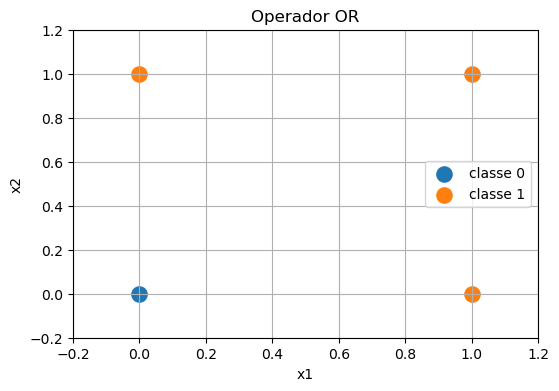

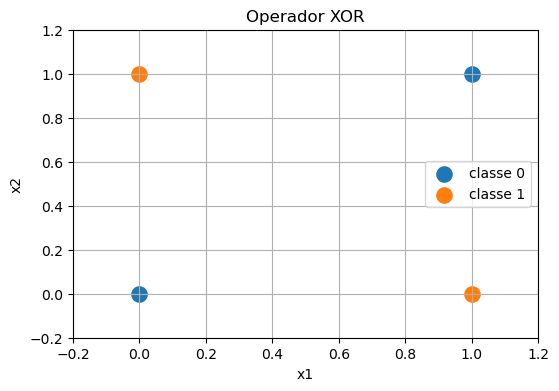

In [4]:
def plot_logic_data(X, y, title="Dados"):
    plt.figure()
    for cls in np.unique(y):
        idx = y == cls
        plt.scatter(X[idx, 0], X[idx, 1], s=120, label=f"classe {cls}")
    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()

X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])

plot_logic_data(X_or, y_or, "Operador OR")
plot_logic_data(X_xor, y_xor, "Operador XOR")

## 3. Implementando o Perceptron do zero

O Perceptron aprende os pesos e o viés a partir dos dados rotulados. A regra de atualização usada aqui é:

$$w \leftarrow w + \eta x_i(y_i - \hat{y}_i)$$

$$b \leftarrow b + \eta(y_i - \hat{y}_i)$$

onde `η` é a taxa de aprendizado.

In [5]:
class PerceptronScratch:
    def __init__(self, learning_rate=0.5, threshold=0.0, max_epochs=20):
        self.learning_rate = learning_rate
        self.threshold = threshold
        self.max_epochs = max_epochs
        self.w = None
        self.b = None
        self.history_ = []

    def _activation(self, v):
        return 1 if v >= self.threshold else 0

    def fit(self, X, y, verbose=True):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.history_ = []

        for epoch in range(1, self.max_epochs + 1):
            updates = 0

            for i in range(n_samples):
                v = np.dot(self.w, X[i]) + self.b
                y_hat = self._activation(v)
                error = y[i] - y_hat

                if error != 0:
                    self.w += self.learning_rate * error * X[i]
                    self.b += self.learning_rate * error
                    updates += 1

            # Mede o desempenho depois das atualizações da época.
            preds_epoch = self.predict(X)
            mistakes_after_epoch = int(np.sum(preds_epoch != y))
            acc = float(np.mean(preds_epoch == y))

            self.history_.append({
                "epoch": epoch,
                "updates": updates,
                "mistakes_after_epoch": mistakes_after_epoch,
                "accuracy": acc,
                "w": self.w.copy(),
                "b": self.b,
            })

            if verbose:
                print(
                    f"Época {epoch:02d} | atualizações: {updates} | "
                    f"erros após época: {mistakes_after_epoch} | "
                    f"acc: {acc:.2f} | w={self.w} | b={self.b:.2f}"
                )

            # Se nenhuma amostra exigiu atualização, o Perceptron convergiu para o conjunto de treino.
            if updates == 0:
                break

        return self

    def predict(self, X):
        v = X @ self.w + self.b
        return step_activation(v, threshold=self.threshold)

### 3.1 Treinando o Perceptron no operador OR

In [6]:
perceptron_or = PerceptronScratch(learning_rate=0.5, threshold=0.0, max_epochs=20)
perceptron_or.fit(X_or, y_or)

print("Predições finais:", perceptron_or.predict(X_or))
print("Saídas esperadas:", y_or)

Época 01 | atualizações: 2 | erros após época: 1 | acc: 0.75 | w=[0.  0.5] | b=0.00
Época 02 | atualizações: 2 | erros após época: 1 | acc: 0.75 | w=[0.5 0.5] | b=0.00
Época 03 | atualizações: 1 | erros após época: 0 | acc: 1.00 | w=[0.5 0.5] | b=-0.50
Época 04 | atualizações: 0 | erros após época: 0 | acc: 1.00 | w=[0.5 0.5] | b=-0.50
Predições finais: [0 1 1 1]
Saídas esperadas: [0 1 1 1]


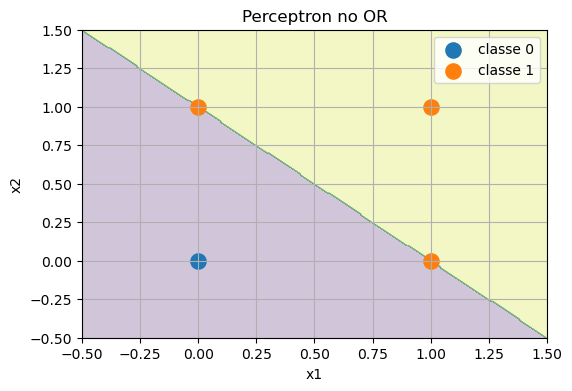

In [7]:
def plot_decision_boundary_binary(model, X, y, title="Fronteira de decisão"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    for cls in np.unique(y):
        idx = y == cls
        plt.scatter(X[idx, 0], X[idx, 1], s=120, label=f"classe {cls}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary_binary(perceptron_or, X_or, y_or, "Perceptron no OR")

### 3.2 Tentando treinar o Perceptron no XOR

Agora repetimos o processo no XOR. A expectativa é que o Perceptron simples não consiga resolver perfeitamente esse problema, pois o XOR não é linearmente separável.

Época 01 | atualizações: 3 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=-0.50
Época 02 | atualizações: 3 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 03 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 04 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 05 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 06 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 07 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 08 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 09 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 10 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 11 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.5  0. ] | b=0.00
Época 12 | atualizações: 4 | erros após época: 2 | ac

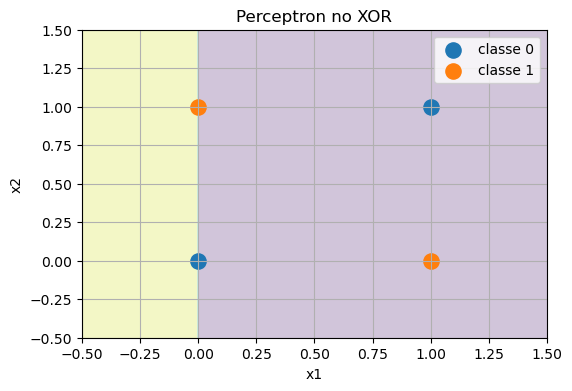

In [8]:
perceptron_xor = PerceptronScratch(learning_rate=0.5, threshold=0.0, max_epochs=20)
perceptron_xor.fit(X_xor, y_xor)

print("Predições finais:", perceptron_xor.predict(X_xor))
print("Saídas esperadas:", y_xor)

plot_decision_boundary_binary(perceptron_xor, X_xor, y_xor, "Perceptron no XOR")

### Atividade 2

Experimente mudar `learning_rate`, `max_epochs`, inicialização dos pesos e ordem das amostras. O Perceptron passa a resolver o XOR? Explique o resultado com base na geometria do problema.

In [ ]:
# Atividade 2 — DONE
# Experimente pelo menos três configurações para learning_rate e/ou max_epochs.
# Registre as predições e a acurácia de cada tentativa.

configs_perceptron = [
    {"learning_rate": 0.1, "threshold": 0.0, "max_epochs": 100},
    {"learning_rate": 0.5, "threshold": 5.0, "max_epochs": 100},
    {"learning_rate": 0.5, "threshold": -5.0, "max_epochs": 100},
    {"learning_rate": 1.5, "threshold": 5.0, "max_epochs": 100},
    {"learning_rate": 1.5, "threshold": -5.0, "max_epochs": 100},
]

# Complete o laço abaixo.
for i, cfg in enumerate(configs_perceptron):
    print(f"\nTest {i}")
    model = PerceptronScratch(**cfg)
    model.fit(X_xor, y_xor)
    print(model.predict(X_xor))


Test 0
Época 01 | atualizações: 3 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=-0.10
Época 02 | atualizações: 3 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 03 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 04 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 05 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 06 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 07 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 08 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 09 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 10 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 11 | atualizações: 4 | erros após época: 2 | acc: 0.50 | w=[-0.1  0. ] | b=0.00
Época 12 | atualizações: 4 | erros após época

Resposta: Foram testadas diferentes configurações, com training_steps e threshholds altos e baixos. Todos foram configurados com um valor consideravelmente alto para o número de épocas. Nenhuma configuração foi suficiente para que o neurônio pudesse aprender a função XOR.
Isso acontece pois as saídas da função XOR não podem ser separadas por uma reta no espaço ao qual elas pertencem.

## 4. Funções de ativação

MLPs usam funções de ativação não lineares, especialmente nas camadas ocultas. Sem não linearidade, várias camadas lineares ainda seriam equivalentes a uma única transformação linear.

Vamos visualizar algumas funções comuns: limiar, logística/sigmoide, tangente hiperbólica e ReLU.

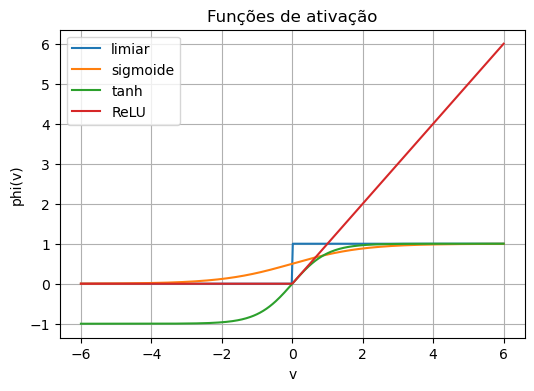

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

z = np.linspace(-6, 6, 400)

plt.figure()
plt.plot(z, step_activation(z, threshold=0), label="limiar")
plt.plot(z, sigmoid(z), label="sigmoide")
plt.plot(z, tanh(z), label="tanh")
plt.plot(z, relu(z), label="ReLU")
plt.xlabel("v")
plt.ylabel("phi(v)")
plt.title("Funções de ativação")
plt.legend()
plt.show()

### Atividade 3

Observe o gráfico e responda:

1. Qual função não é diferenciável no ponto de transição?
2. Qual função produz valores entre 0 e 1?
3. Qual função produz valores entre -1 e 1?
4. Por que a ReLU costuma ser útil em camadas ocultas?

### Resposta da Atividade 3

1. Limiar e ReLU
2. Sigmoid
3. Tanh
4. TODO

## 5. Uma MLP do zero para resolver XOR

Agora vamos construir uma rede com:

- 2 entradas (`x1`, `x2`)
- 1 camada oculta
- 1 saída binária
- ativação `tanh` na camada oculta
- ativação `sigmoid` na saída
- custo de entropia cruzada binária

A ativação da rede terá a forma:

$$X \rightarrow Z_1 = XW_1 + b_1 \rightarrow A_1 = \tanh(Z_1) \rightarrow Z_2 = A_1W_2 + b_2 \rightarrow \hat{Y} = \sigma(Z_2)$$

### Função de Custo: Entropia Cruzada Binária

Para problemas de classificação binária, a função de custo mais comum é a entropia cruzada binária. Ela mede a diferença entre a distribuição de probabilidade real (os rótulos `y`) e a distribuição de probabilidade prevista pela rede (`A2`).

A fórmula para a entropia cruzada binária é:

$$ E = -\frac{1}{n_{samples}} \sum_{i=1}^{n_{samples}} [y_i \log(A_{2,i}) + (1 - y_i) \log(1 - A_{2,i})] $$

O objetivo do treinamento é minimizar essa função de custo.

In [11]:
def binary_cross_entropy(y_true, y_pred):
    """Calcula a entropia cruzada binária."""
    # Evita logaritmo de zero
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

## Entendendo o Backpropagation

O *backpropagation* é o algoritmo central para treinar redes neurais, permitindo ajustar os pesos e vieses da rede de forma eficiente. Ele consiste em três fases principais:

1.  **Forward Pass**: Calcula as saídas da rede para uma dada entrada, armazenando os valores intermediários em cada camada.
2.  **Cálculo da Função de Custo**: Compara a saída da rede com os valores esperados (`y`) para quantificar o erro da predição.
3.  **Backward Pass (Propagação do Erro)**: Calcula as derivadas parciais da função de custo em relação a cada peso e viés (os gradientes), trabalhando da camada de saída para trás. Este é o cerne do *backpropagation*.

### Princípio da Regra da Cadeia

O *backward pass* utiliza intensamente a regra da cadeia para calcular como uma pequena mudança em um peso ou viés afeta a função de custo. Basicamente, para um parâmetro genérico $\theta$ em uma camada e uma função de custo $E$, o gradiente é calculado como:

$$ \frac{\partial E}{\partial \theta} = \frac{\partial E}{\partial \text{Saída da Camada}} \times \frac{\partial \text{Saída da Camada}}{\partial \theta} $$

Essa multiplicação de derivadas é realizada sequencialmente, retrocedendo pela rede. Por exemplo, a derivada da função de custo em relação aos pesos da camada de saída (`W2`) depende da derivada do custo em relação à saída linear (`Z2`), que por sua vez depende dos pesos `W2`:

$$ \frac{\partial E}{\partial W_2} = \frac{\partial E}{\partial Z_2} \times \frac{\partial Z_2}{\partial W_2} $$

E, de forma similar, para os pesos da camada oculta (`W1`):

$$ \frac{\partial E}{\partial W_1} = \frac{\partial E}{\partial Z_2} \times \frac{\partial Z_2}{\partial A_1} \times \frac{\partial A_1}{\partial Z_1} \times \frac{\partial Z_1}{\partial W_1} $$

### Atualização dos Parâmetros

Uma vez que todos os gradientes são calculados, os pesos e vieses são ajustados em uma direção que minimiza a função de custo, usando a taxa de aprendizado ($\eta$) para controlar o tamanho do passo:

$$ \theta \leftarrow \theta - \eta \frac{\partial E}{\partial \theta} $$

As seções a seguir detalham o cálculo de cada uma dessas derivadas parciais específicas para a nossa MLP binária.

### Derivada da função de custo em relação a Z2 (Saída da camada de saída)

Esta função calcula $\frac{\partial E}{\partial Z_2}$. Para a combinação de função de ativação sigmoide ($\sigma(z) = \frac{1}{1 + e^{-z}}$) na saída e a função de custo de entropia cruzada binária ($E = -\frac{1}{n_{samples}} \sum_{i=1}^{n_{samples}} [y_i \log(A_{2,i}) + (1 - y_i) \log(1 - A_{2,i})]$), a derivada se simplifica convenientemente para $A_2 - y$ (predição - valor real).

In [12]:
def _backward_dZ2(A2, y):
    """Calcula a derivada da função de custo em relação a Z2 (camada de saída)."""
    return A2 - y

### Derivada da função de custo em relação aos pesos W2

Esta função calcula $\frac{\partial E}{\partial W_2}$. Usando a regra da cadeia, temos $\frac{\partial E}{\partial W_2} = \frac{\partial E}{\partial Z_2} \times \frac{\partial Z_2}{\partial W_2}$. Como $Z_2 = A_1 W_2 + b_2$, a derivada de $Z_2$ em relação a $W_2$ é $A_1^T$. Multiplicamos por $\frac{1}{n_{samples}}$ para obter a média do gradiente.

$$ \frac{\partial E}{\partial W_2} = \frac{1}{n_{samples}} A_1^T \frac{\partial E}{\partial Z_2} $$

In [13]:
def _backward_dW2(A1, dZ2, n_samples):
    """Calcula a derivada da função de custo em relação aos pesos W2."""
    return A1.T @ dZ2 / n_samples

### Derivada da função de custo em relação ao viés b2

Esta função calcula $\frac{\partial E}{\partial b_2}$. Usando a regra da cadeia, temos $\frac{\partial E}{\partial b_2} = \frac{\partial E}{\partial Z_2} \times \frac{\partial Z_2}{\partial b_2}$. Como $Z_2 = A_1 W_2 + b_2$, a derivada de $Z_2$ em relação a $b_2$ é $1$. Tomamos a média sobre as amostras.

$$ \frac{\partial E}{\partial b_2} = \frac{1}{n_{samples}} \sum \frac{\partial E}{\partial Z_2} $$

In [14]:
def _backward_db2(dZ2):
    """Calcula a derivada da função de custo em relação ao viés b2."""
    return np.mean(dZ2, axis=0, keepdims=True)

### Derivada da função de custo em relação à ativação A1 (Camada Oculta)

Esta função calcula $\frac{\partial E}{\partial A_1}$. Isso é necessário para propagar o erro de volta para a camada oculta. Usando a regra da cadeia, $\frac{\partial E}{\partial A_1} = \frac{\partial E}{\partial Z_2} \times \frac{\partial Z_2}{\partial A_1}$. Como $Z_2 = A_1 W_2 + b_2$, a derivada de $Z_2$ em relação a $A_1$ é $W_2^T$.

$$ \frac{\partial E}{\partial A_1} = \frac{\partial E}{\partial Z_2} W_2^T $$

In [15]:
def _backward_dA1(dZ2, W2):
    """Calcula a derivada da função de custo em relação à ativação A1 (camada oculta)."""
    return dZ2 @ W2.T

### Derivada da função de custo em relação a Z1 (Saída da camada oculta, antes da ativação)

Esta função calcula $\frac{\partial E}{\partial Z_1}$. Usando a regra da cadeia, $\frac{\partial E}{\partial Z_1} = \frac{\partial E}{\partial A_1} \times \frac{\partial A_1}{\partial Z_1}$. Como $A_1 = \tanh(Z_1)$, a derivada de $A_1$ em relação a $Z_1$ é $1 - \tanh(Z_1)^2$.

$$ \frac{\partial E}{\partial Z_1} = \frac{\partial E}{\partial A_1} \odot (1 - \tanh(Z_1)^2) $$

In [16]:
def _backward_dZ1(dA1, Z1):
    """Calcula a derivada da função de custo em relação a Z1 (camada oculta)."""
    return dA1 * (1 - np.tanh(Z1)**2)

### Derivada da função de custo em relação ao viés b1

Esta função calcula $\frac{\partial E}{\partial b_1}$. Usando a regra da cadeia, $\frac{\partial E}{\partial b_1} = \frac{\partial E}{\partial Z_1} \times \frac{\partial Z_1}{\partial b_1}$. Como $Z_1 = X W_1 + b_1$, a derivada de $Z_1$ em relação a $b_1$ é $1$. Tomamos a média sobre as amostras.

$$ \frac{\partial E}{\partial b_1} = \frac{1}{n_{samples}} \sum \frac{\partial E}{\partial Z_1} $$

In [17]:
def _backward_db1(dZ1):
    """Calcula a derivada da função de custo em relação ao viés b1."""
    return np.mean(dZ1, axis=0, keepdims=True)

### Derivada da função de custo em relação aos pesos W1

Esta função calcula $\frac{\partial E}{\partial W_1}$. Usando a regra da cadeia, $\frac{\partial E}{\partial W_1} = \frac{\partial E}{\partial Z_1} \times \frac{\partial Z_1}{\partial W_1}$. Como $Z_1 = X W_1 + b_1$, a derivada de $Z_1$ em relação a $W_1$ é $X^T$. Multiplicamos por $\frac{1}{n_{samples}}$ para obter a média do gradiente.

$$ \frac{\partial E}{\partial W_1} = \frac{1}{n_{samples}} X^T \frac{\partial E}{\partial Z_1} $$

In [18]:
def _backward_dW1(X, dZ1, n_samples):
    """Calcula a derivada da função de custo em relação aos pesos W1."""
    return X.T @ dZ1 / n_samples

### 5.1 Implementação Completa da MLP (MLPBinaryScratch)

Agora, vamos integrar todas as funções que definimos para o *forward* e *backward pass* em uma classe completa, a `MLPBinaryScratch`. Esta classe será responsável por construir, treinar e fazer predições com uma Perceptron Multicamadas para problemas de classificação binária, utilizando todas as derivadas calculadas para o *backpropagation*.

In [19]:
class MLPBinaryScratch:
    def __init__(self, hidden_units=4, learning_rate=0.5, epochs=5000, seed=42):
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.seed = seed
        self.loss_history_ = []
        self.last_grads_ = None

    def _initialize(self, n_features):
        # Inicializa pesos e vieses com valores aleatórios pequenos.
        rng = np.random.default_rng(self.seed)
        self.W1 = rng.normal(0, 1, size=(n_features, self.hidden_units)) * 0.5
        self.b1 = np.zeros((1, self.hidden_units))
        self.W2 = rng.normal(0, 1, size=(self.hidden_units, 1)) * 0.5
        self.b2 = np.zeros((1, 1))

    def _forward(self, X):
        # Camada de entrada para oculta.
        Z1 = X @ self.W1 + self.b1
        A1 = np.tanh(Z1)

        # Camada oculta para saída.
        Z2 = A1 @ self.W2 + self.b2
        A2 = sigmoid(Z2)

        cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
        return A2, cache

    def compute_gradients(self, X, y):
        """Calcula os gradientes nos parâmetros atuais da rede."""
        y = y.reshape(-1, 1)
        n_samples = X.shape[0]
        A2, cache = self._forward(X)

        dZ2 = _backward_dZ2(A2, y)
        dW2 = _backward_dW2(cache["A1"], dZ2, n_samples)
        db2 = _backward_db2(dZ2)

        dA1 = _backward_dA1(dZ2, self.W2)
        dZ1 = _backward_dZ1(dA1, cache["Z1"])
        dW1 = _backward_dW1(cache["X"], dZ1, n_samples)
        db1 = _backward_db1(dZ1)

        return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

    def fit(self, X, y, verbose_every=500):
        y = y.reshape(-1, 1)
        n_samples, n_features = X.shape
        self._initialize(n_features)
        self.loss_history_ = []
        self.last_grads_ = None

        for epoch in range(1, self.epochs + 1):
            A2, cache = self._forward(X)
            loss = binary_cross_entropy(y, A2)
            self.loss_history_.append(loss)

            # Backward pass.
            dZ2 = _backward_dZ2(A2, y)
            dW2 = _backward_dW2(cache["A1"], dZ2, n_samples)
            db2 = _backward_db2(dZ2)
            dA1 = _backward_dA1(dZ2, self.W2)
            dZ1 = _backward_dZ1(dA1, cache["Z1"])
            dW1 = _backward_dW1(cache["X"], dZ1, n_samples)
            db1 = _backward_db1(dZ1)

            self.last_grads_ = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

            # Atualização dos parâmetros usando gradiente descendente.
            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2
            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

            if verbose_every and epoch % verbose_every == 0:
                print(f"Época {epoch:05d} | loss={loss:.6f}")

        return self

    def predict_proba(self, X):
        A2, _ = self._forward(X)
        return A2.ravel()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [20]:
mlp_xor = MLPBinaryScratch(hidden_units=4, learning_rate=0.8, epochs=5000, seed=1)
mlp_xor.fit(X_xor.astype(float), y_xor, verbose_every=1000)

print("Probabilidades:", np.round(mlp_xor.predict_proba(X_xor), 4))
print("Predições:     ", mlp_xor.predict(X_xor))
print("Esperado:      ", y_xor)

Época 01000 | loss=0.003220
Época 02000 | loss=0.001526
Época 03000 | loss=0.000999
Época 04000 | loss=0.000743
Época 05000 | loss=0.000591
Probabilidades: [1.000e-04 9.993e-01 9.993e-01 1.000e-03]
Predições:      [0 1 1 0]
Esperado:       [0 1 1 0]


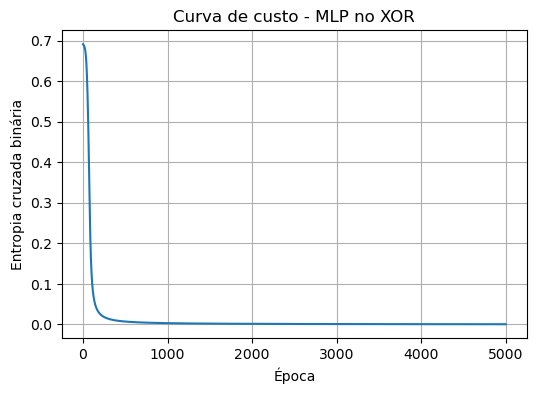

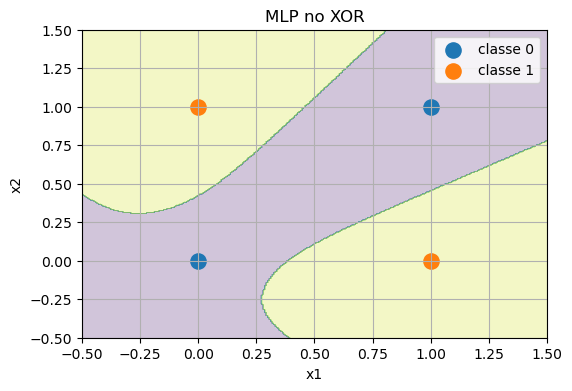

In [21]:
plt.figure()
plt.plot(mlp_xor.loss_history_)
plt.xlabel("Época")
plt.ylabel("Entropia cruzada binária")
plt.title("Curva de custo - MLP no XOR")
plt.show()

plot_decision_boundary_binary(mlp_xor, X_xor, y_xor, "MLP no XOR")

### Atividade 4

Treine a MLP com diferentes valores:

- `hidden_units = 1, 2, 4, 8`
- `learning_rate = 0.01, 0.1, 0.8, 2.0`
- `epochs = 500, 2000, 10000`
- `seed = 1, 2, 3, 4, 5`

Registre em uma tabela: configuração, custo final, acurácia e observações sobre a fronteira de decisão.

In [22]:
# Atividade 4 — DONE
# Treine diferentes configurações da MLP do zero no XOR.
# Preencha a lista `configs` com pelo menos 5 configurações e calcule custo final e acurácia.

def evaluate_mlp_configs(X, y, configs):
    rows = []
    for cfg in configs:
        # DONE: instanciar MLPBinaryScratch com cfg
        mlp = MLPBinaryScratch(**cfg)
        # DONE: treinar o modelo
        mlp.fit(X, y)
        # DONE: calcular predições, custo final e acurácia
        rows.append(
            {
                "config": cfg,
                "final_loss": mlp.loss_history_[-1],
                "accuracy": np.mean(mlp.predict(X) == y)
            }
        )
    return rows

configs = [
    {"hidden_units": 4, "learning_rate": 0.1, "epochs": 100, "seed": 42},
    {"hidden_units": 4, "learning_rate": 0.01, "epochs": 100, "seed": 42},
    {"hidden_units": 4, "learning_rate": 0.5, "epochs": 100, "seed": 42},
    {"hidden_units": 8, "learning_rate": 0.1, "epochs": 100, "seed": 42},
    {"hidden_units": 16, "learning_rate": 0.1, "epochs": 100, "seed": 42},
    {"hidden_units": 32, "learning_rate": 0.1, "epochs": 100, "seed": 42},
    {"hidden_units": 64, "learning_rate": 0.1, "epochs": 100, "seed": 42}
]

results = evaluate_mlp_configs(X_xor.astype(float), y_xor, configs)
for row in results:
    print(row)

{'config': {'hidden_units': 4, 'learning_rate': 0.1, 'epochs': 100, 'seed': 42}, 'final_loss': np.float64(0.6711864930013612), 'accuracy': np.float64(0.5)}
{'config': {'hidden_units': 4, 'learning_rate': 0.01, 'epochs': 100, 'seed': 42}, 'final_loss': np.float64(0.6945436825641982), 'accuracy': np.float64(0.75)}
{'config': {'hidden_units': 4, 'learning_rate': 0.5, 'epochs': 100, 'seed': 42}, 'final_loss': np.float64(0.4475376137538941), 'accuracy': np.float64(0.75)}
{'config': {'hidden_units': 8, 'learning_rate': 0.1, 'epochs': 100, 'seed': 42}, 'final_loss': np.float64(0.6598900320331239), 'accuracy': np.float64(0.5)}
{'config': {'hidden_units': 16, 'learning_rate': 0.1, 'epochs': 100, 'seed': 42}, 'final_loss': np.float64(0.638510398805916), 'accuracy': np.float64(0.75)}
{'config': {'hidden_units': 32, 'learning_rate': 0.1, 'epochs': 100, 'seed': 42}, 'final_loss': np.float64(0.6018176879042102), 'accuracy': np.float64(1.0)}
{'config': {'hidden_units': 64, 'learning_rate': 0.1, 'epoc

## 6. Verificação numérica do gradiente

Backpropagation calcula derivadas de forma eficiente. Uma forma de ganhar confiança na implementação é comparar uma derivada analítica com uma aproximação numérica:

$$\frac{\partial E}{\partial \theta} \approx \frac{E(\theta + \epsilon) - E(\theta - \epsilon)}{2\epsilon}$$

Abaixo verificamos um único peso da primeira camada.

In [23]:
def compute_loss_for_current_params(model, X, y):
    proba = model.predict_proba(X).reshape(-1, 1)
    return binary_cross_entropy(y.reshape(-1, 1), proba)

model_check = MLPBinaryScratch(hidden_units=3, learning_rate=0.5, epochs=10, seed=0)
model_check.fit(X_xor.astype(float), y_xor, verbose_every=None)

epsilon = 1e-5
original = model_check.W1[0, 0]

model_check.W1[0, 0] = original + epsilon
loss_plus = compute_loss_for_current_params(model_check, X_xor.astype(float), y_xor)

model_check.W1[0, 0] = original - epsilon
loss_minus = compute_loss_for_current_params(model_check, X_xor.astype(float), y_xor)

model_check.W1[0, 0] = original
numeric_grad = (loss_plus - loss_minus) / (2 * epsilon)

analytic_grads = model_check.compute_gradients(X_xor.astype(float), y_xor)
analytic_grad = analytic_grads["dW1"][0, 0]

print("Gradiente numérico aproximado para W1[0,0]:", numeric_grad)
print("Gradiente analítico por backprop para W1[0,0]:", analytic_grad)
print("Diferença absoluta:", abs(numeric_grad - analytic_grad))

Gradiente numérico aproximado para W1[0,0]: -0.0031732690142227678
Gradiente analítico por backprop para W1[0,0]: -0.0031732690205844294
Diferença absoluta: 6.361661631509863e-12


### Resposta da Atividade 5

- Valor do gradiente numérico: -0.0031732690142227678
- Valor do gradiente analítico: -0.0031732690205844294
- Diferença absoluta: 6.361661631509863e-12

Discussão: O erro do valor numérico para o valor analítico é desprezível. Isso demonstra que a solução analítica provavelmente está correta e pode ser usada para cálculo do gradiente.

## 7. Um problema não linear com mais dados: duas luas

Agora vamos sair das tabelas verdade e criar um conjunto de dados sintético com fronteira não linear. Usaremos o `scikit-learn` para gerar os dados e, depois, para comparar com uma MLP pronta.

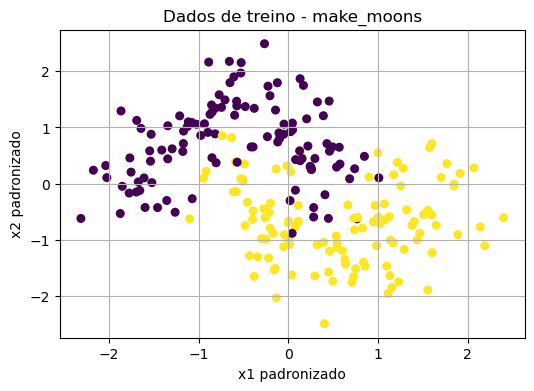

In [24]:
try:
    from sklearn.datasets import make_moons
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.neural_network import MLPClassifier
    from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn não está instalado. Instale com: pip install scikit-learn")

if SKLEARN_AVAILABLE:
    X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    plt.figure()
    plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, s=30)
    plt.xlabel("x1 padronizado")
    plt.ylabel("x2 padronizado")
    plt.title("Dados de treino - make_moons")
    plt.show()

## 8. Treinando uma MLP pronta com `scikit-learn`

A implementação abaixo usa `MLPClassifier`. Ela permite focar no uso prático: divisão treino/teste, padronização, ajuste de hiperparâmetros e avaliação.

In [25]:
if SKLEARN_AVAILABLE:
    clf = MLPClassifier(
        hidden_layer_sizes=(8, 8),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.01,
        max_iter=500,
        random_state=42
    )

    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    y_pred_test = clf.predict(X_test_scaled)

    print("Acurácia treino:", accuracy_score(y_train, y_pred_train))
    print("Acurácia teste: ", accuracy_score(y_test, y_pred_test))
    print("\nRelatório de classificação no teste:")
    print(classification_report(y_test, y_pred_test))

Acurácia treino: 0.9466666666666667
Acurácia teste:  0.92

Relatório de classificação no teste:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92        38
           1       0.88      0.97      0.92        37

    accuracy                           0.92        75
   macro avg       0.92      0.92      0.92        75
weighted avg       0.92      0.92      0.92        75



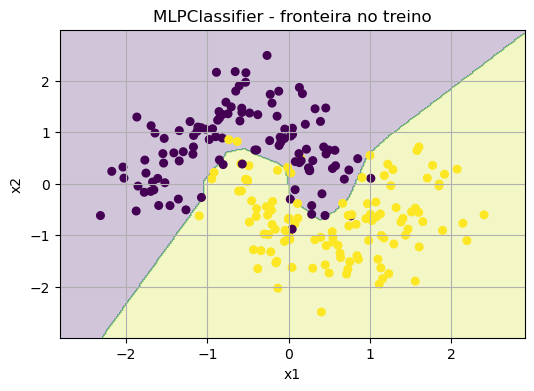

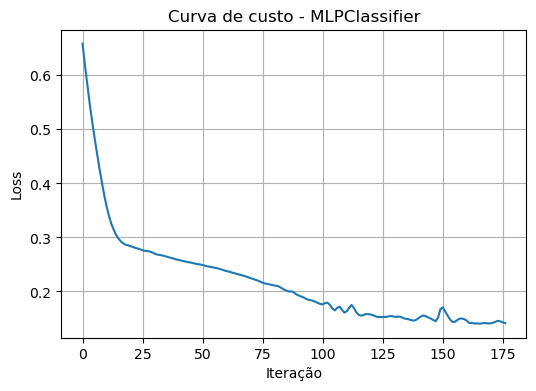

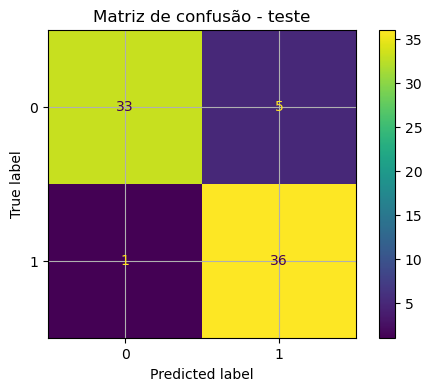

In [26]:
def plot_decision_boundary_sklearn(model, X, y, title="Fronteira de decisão"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

if SKLEARN_AVAILABLE:
    plot_decision_boundary_sklearn(clf, X_train_scaled, y_train, "MLPClassifier - fronteira no treino")

    if hasattr(clf, "loss_curve_"):
        plt.figure()
        plt.plot(clf.loss_curve_)
        plt.xlabel("Iteração")
        plt.ylabel("Loss")
        plt.title("Curva de custo - MLPClassifier")
        plt.show()

    ConfusionMatrixDisplay.from_estimator(clf, X_test_scaled, y_test)
    plt.title("Matriz de confusão - teste")
    plt.show()

### Atividade 6: experimento guiado de hiperparâmetros

Compare pelo menos cinco configurações diferentes. Sugestões:

1. Uma rede pequena: `(2,)`
2. Uma rede média: `(8, 8)`
3. Uma rede maior: `(32, 32)`
4. Ativação `tanh`
5. Ativação `relu`
6. Taxa de aprendizado inicial menor: `0.001`
7. Taxa de aprendizado inicial maior: `0.05`

Cuidado: redes maiores podem memorizar melhor o treino, mas nem sempre melhoram o teste.

In [ ]:
# Atividade 6 — DONE
# Compare pelo menos cinco configurações diferentes do MLPClassifier.
# Para cada uma, registre acurácia de treino, acurácia de teste, número de iterações e custo final.

if SKLEARN_AVAILABLE:
    experiments = [
        {"hidden_layer_sizes": 10, "activation": "relu", "learning_rate_init": 0.01},
        {"hidden_layer_sizes": 10, "activation": "tanh", "learning_rate_init": 0.01},
        {"hidden_layer_sizes": 100, "activation": "relu", "learning_rate_init": 0.01},
        {"hidden_layer_sizes": 100, "activation": "relu", "learning_rate_init": 0.001},
        {"hidden_layer_sizes": 2, "activation": "relu", "learning_rate_init": 0.001},
        {"hidden_layer_sizes": 2, "activation": "relu", "learning_rate_init": 0.01},
    ]

    summary = []
    for i, params in enumerate(experiments):
        # TODO: instanciar MLPClassifieri, model.sco
        model = MLPClassifier(**params)
        # TODO: treinar no conjunto de treino padronizado
        model.fit(X_train_scaled, y_train)
        # TODO: calcular métricas no treino e no teste
        summary.append((i, accuracy_score(y_train, model.predict(X_train_scaled)), accuracy_score(y_test, model.predict(X_test_scaled))))
        pass

    for row in summary:
        print(row)

/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(0, 0.9288888888888889, 0.9066666666666666)
(1, 0.9022222222222223, 0.8933333333333333)
(2, 0.9333333333333333, 0.9466666666666667)
(3, 0.88, 0.8666666666666667)
(4, 0.5022222222222222, 0.49333333333333335)
(5, 0.8711111111111111, 0.8533333333333334)


## 9. Mini-projeto: classificação de dígitos escritos à mão

Neste mini-projeto, a rede recebe uma imagem 8x8 de um dígito e deve classificar qual número aparece. Esse exemplo mostra uma aplicação multiclasse com uma camada de saída que representa várias classes.

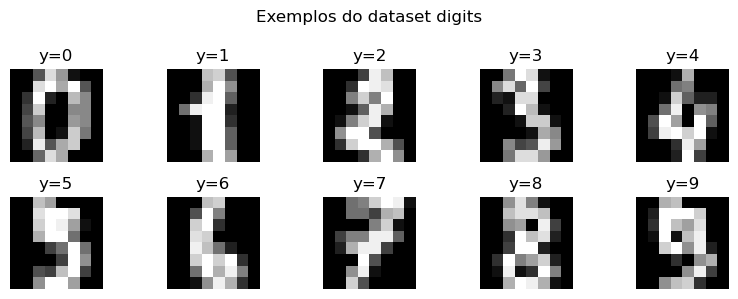

In [28]:
if SKLEARN_AVAILABLE:
    from sklearn.datasets import load_digits
    from sklearn.metrics import ConfusionMatrixDisplay

    digits = load_digits()
    X_digits = digits.data / 16.0  # pixels originalmente variam de 0 a 16
    y_digits = digits.target

    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X_digits, y_digits, test_size=0.25, random_state=42, stratify=y_digits
    )

    fig = plt.figure(figsize=(8, 3))
    for i in range(10):
        ax = fig.add_subplot(2, 5, i + 1)
        ax.imshow(digits.images[i], cmap="gray")
        ax.set_title(f"y={digits.target[i]}")
        ax.axis("off")
    plt.suptitle("Exemplos do dataset digits")
    plt.tight_layout()
    plt.show()

Acurácia no teste: 0.9822222222222222
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       0.92      0.98      0.95        46
           2       1.00      1.00      1.00        44
           3       1.00      1.00      1.00        46
           4       0.98      1.00      0.99        45
           5       1.00      0.98      0.99        46
           6       1.00      0.98      0.99        45
           7       1.00      1.00      1.00        45
           8       0.95      0.91      0.93        43
           9       0.98      1.00      0.99        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



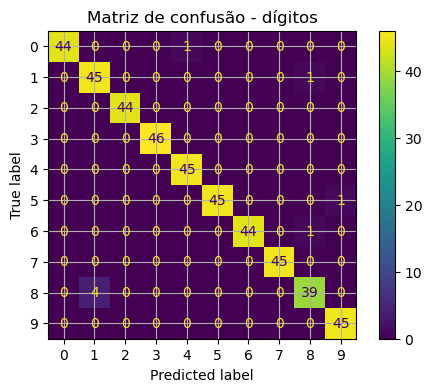

In [48]:
if SKLEARN_AVAILABLE:
    digit_clf = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        alpha=0.0001,
        max_iter=500,
        random_state=42
    )

    digit_clf.fit(X_train_d, y_train_d)
    pred_d = digit_clf.predict(X_test_d)

    print("Acurácia no teste:", accuracy_score(y_test_d, pred_d))
    print(classification_report(y_test_d, pred_d))

    ConfusionMatrixDisplay.from_estimator(digit_clf, X_test_d, y_test_d)
    plt.title("Matriz de confusão - dígitos")
    plt.show()

### Atividade 7: análise de erros

Escolha alguns exemplos classificados incorretamente e visualize as imagens. Tente responder:

1. Quais dígitos a rede mais confunde?
2. Os exemplos errados parecem ambíguos para humanos?
3. Aumentar a rede melhora a acurácia no teste?
4. O que acontece ao reduzir muito o número de neurônios?

(450, 64) (450,)
Número de erros: 8
[ 25  62 200 238 242 255 310 329]


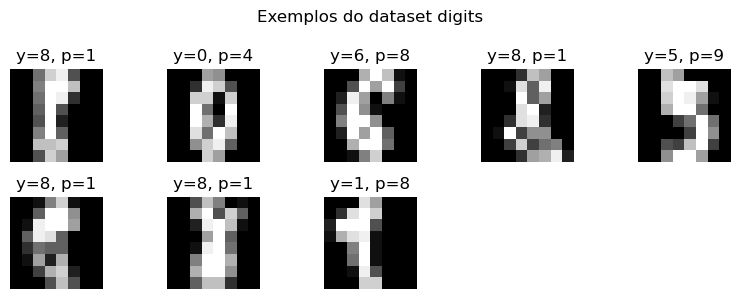

In [71]:
# Atividade 7 — TODO
# Encontre exemplos classificados incorretamente e visualize algumas imagens.
# Em seguida, responda às perguntas da atividade em uma célula Markdown.
print(X_test_d.shape, y_test_d.shape)
if SKLEARN_AVAILABLE:
    wrong = np.where(pred_d != y_test_d)[0]
    print(f"Número de erros: {len(wrong)}")
    print(wrong)
    # TODO: visualizar alguns exemplos incorretos
    # Dica: use X_test_d[idx].reshape(8, 8), y_test_d[idx] e pred_d[idx].
    fig = plt.figure(figsize=(8, 3))
    for i, idx in enumerate(wrong):
        ax = fig.add_subplot(2, 5, i + 1)
        ax.imshow(X_test_d[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"y={y_test_d[idx]}, p={pred_d[idx]}")
        ax.axis("off")
    plt.suptitle("Exemplos do dataset digits")
    plt.tight_layout()
    plt.show()
    print()

Respostas
1. Além de alguns erros isolados, a rede confundiu vários 8 e 1. Essa confusão aumenta diminuindo o número de neurônios ocultos na rede.
2. A maior parte dos exemplos parece ambígua. 1's e 8's são parecidos pela baixa resolução. A entrada 242 é um 5 no qual a parte de cima está borrada, parecendo um 9. Mas o erro do exemplo 62 parece arbitrário
3. Aumentar ou diminuir levemente o número de neurônios ocultos não apresentou mudança significante no resultado do teste, que ficou em torno de 98%.
4. Apenas para valores menores que 5, o desempenho do modelo começou a diminuir significativamente  

## 10. Síntese conceitual

Ao final desta aula, você deve ser capaz de explicar:

- Um neurônio artificial calcula uma combinação linear das entradas e aplica uma função de ativação.
- O Perceptron aprende uma fronteira linear e funciona bem em problemas linearmente separáveis.
- O XOR evidencia a limitação de uma única fronteira linear.
- Uma MLP combina camadas, pesos, vieses e ativações não lineares para modelar fronteiras mais complexas.
- O treinamento usa uma função de custo para medir erro e backpropagation para calcular gradientes.
- Hiperparâmetros afetam o aprendizado, a estabilidade e a generalização.

## Entrega sugerida

Entregue um notebook executado contendo:

1. Resultados do Perceptron em OR e XOR.
2. Gráficos das fronteiras de decisão.
3. Pelo menos três experimentos com a MLP do zero no XOR.
4. Pelo menos cinco experimentos com `MLPClassifier` no problema das duas luas.
5. Uma análise curta sobre desempenho, hiperparâmetros e limitações observadas.

## Desafio opcional

Implemente uma MLP multiclasse do zero usando `softmax` e entropia cruzada categórica. Depois, teste no dataset `digits`.